DATA CLEANING AND FEATURE ENGINEERING

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (train_test_split, cross_validate,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

In [66]:
df = pd.read_csv('bank-additional-full.csv', sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


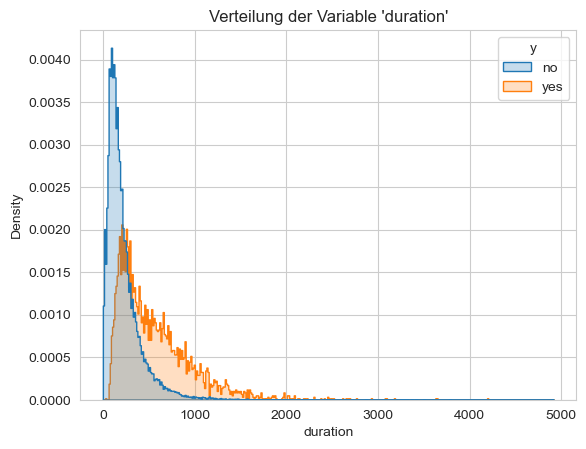

In [74]:
sns.histplot(data=df, x='duration', hue="y", element="step", stat="density", common_norm=False)
plt.title("Verteilung der Variable 'duration'")
plt.savefig("verteilung_der_variable_duration.png")
plt.show()

In [18]:
df = df.drop('duration', axis=1)

In [19]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

EDA

In [20]:
df.shape

(41188, 20)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [22]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int64
dtype: object

In [23]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [24]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


Text(0.5, 1.0, 'Termineinlage-Anzahl')

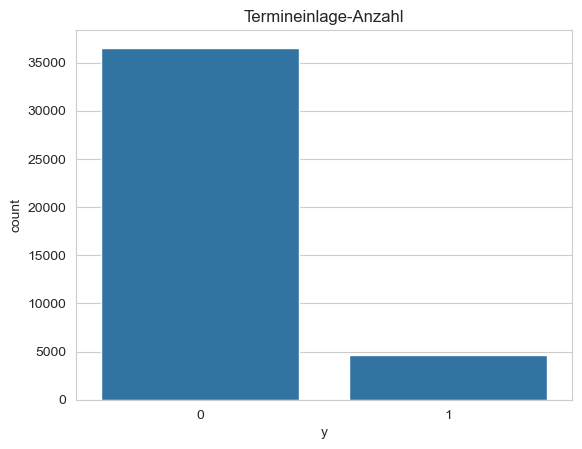

In [25]:
sns.countplot(data=df, x="y")
plt.savefig('target_countplot.png')
plt.title("Termineinlage-Anzahl")

In [26]:
numeric_cols = ["age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

KeyError: "['duration'] not in index"

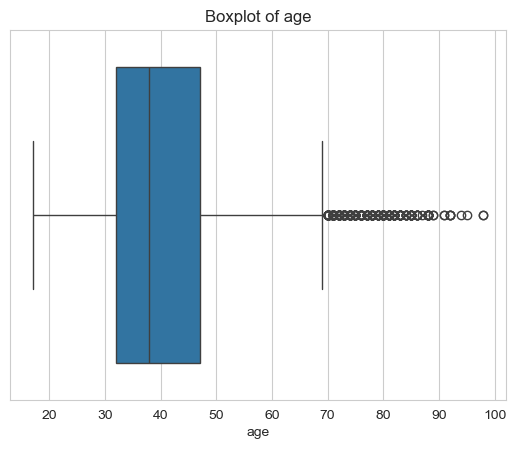

KeyError: 'duration'

In [37]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

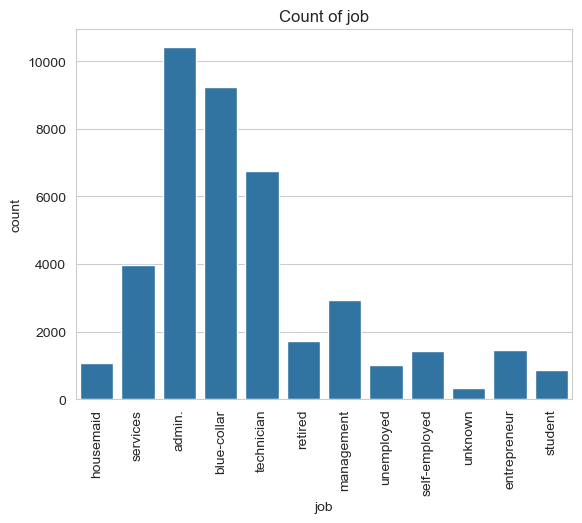

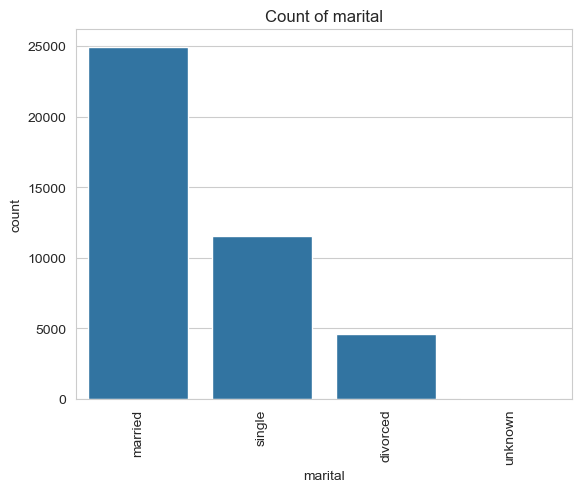

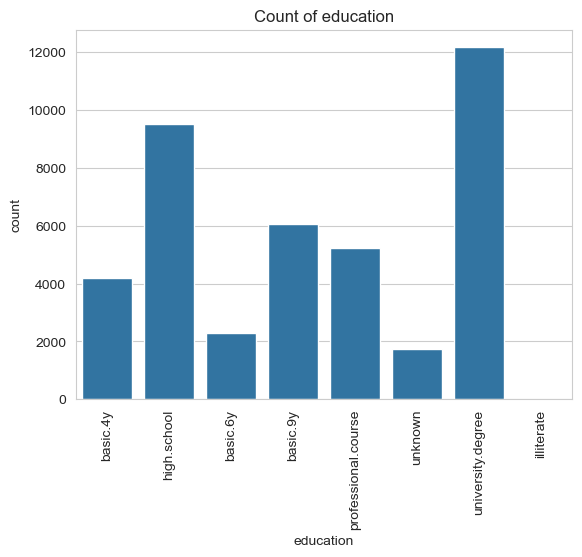

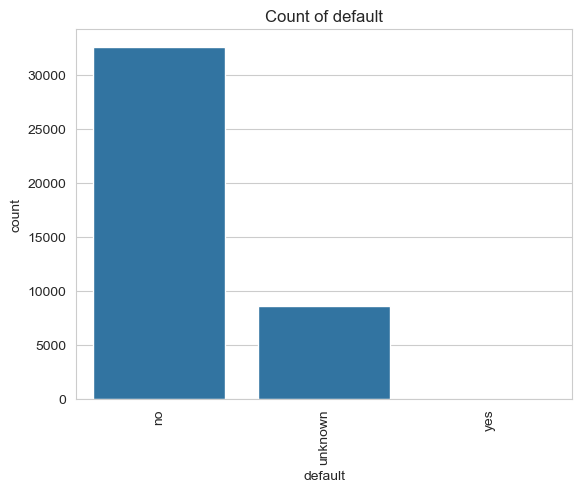

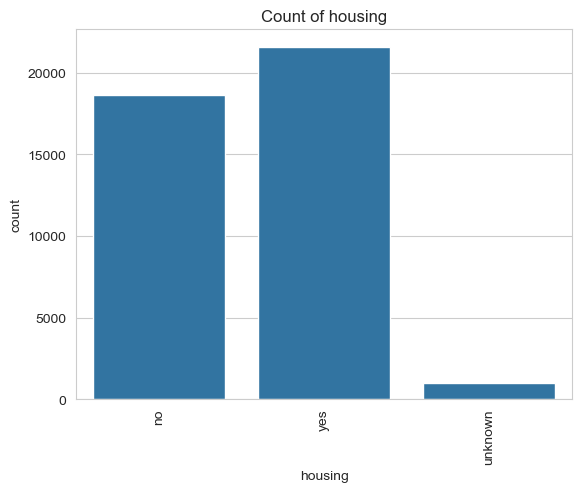

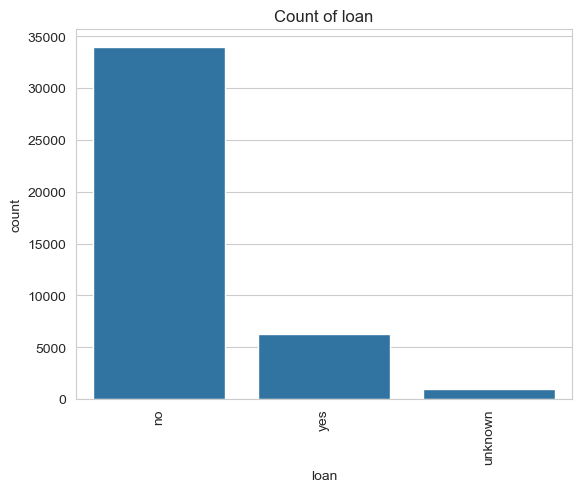

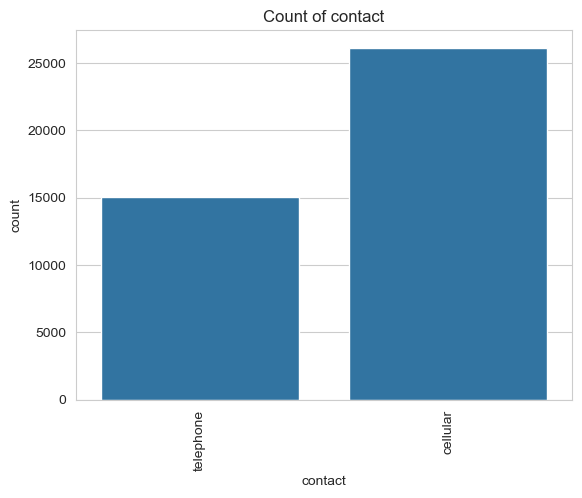

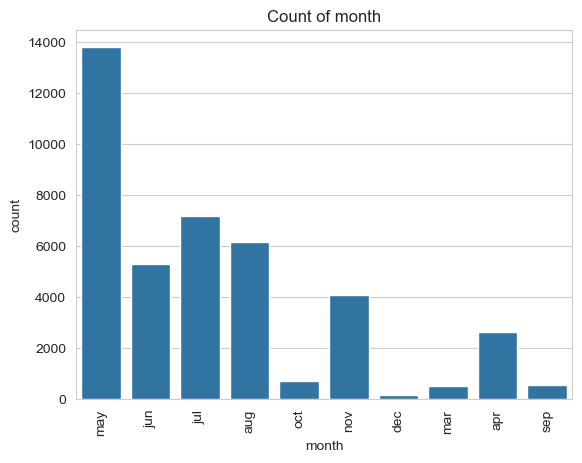

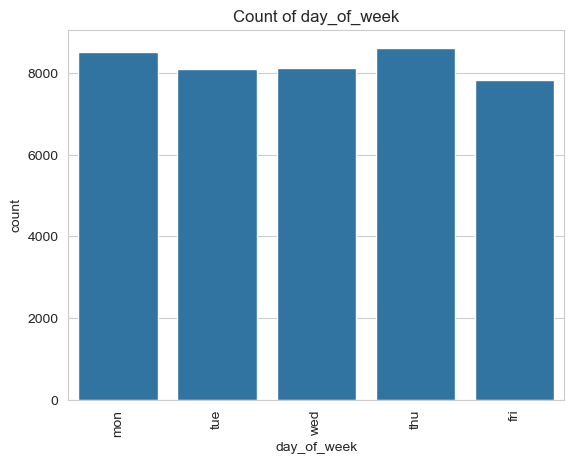

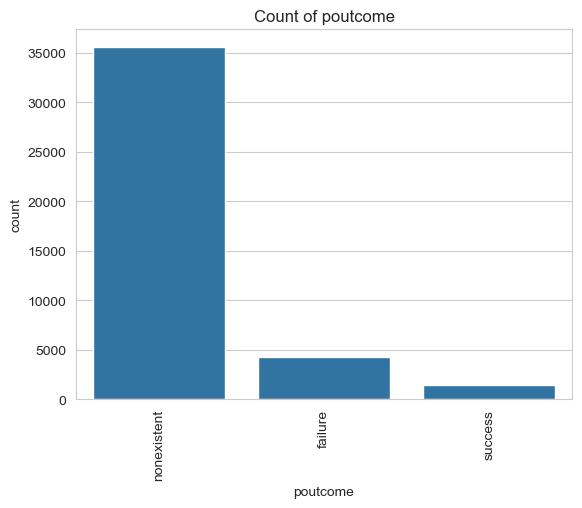

In [27]:
categorical_cols = [col for col in df.columns if df[col].dtypes == object]

for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=90)
    plt.show()

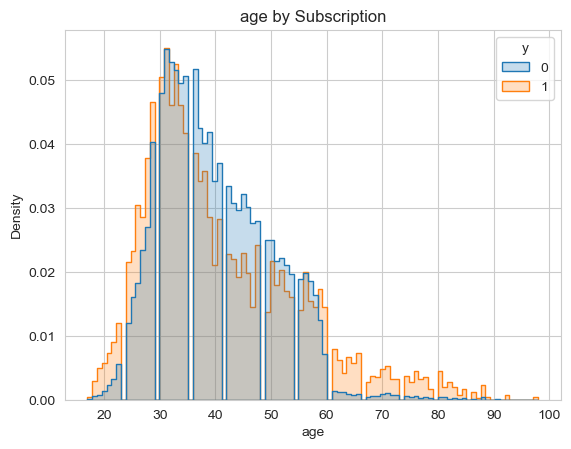

ValueError: Could not interpret value `duration` for `x`. An entry with this name does not appear in `data`.

In [28]:
for col in numeric_cols:
    sns.histplot(data=df, x=col, hue="y", element="step", stat="density", common_norm=False)
    plt.title(f"{col} by Subscription")
    plt.show()

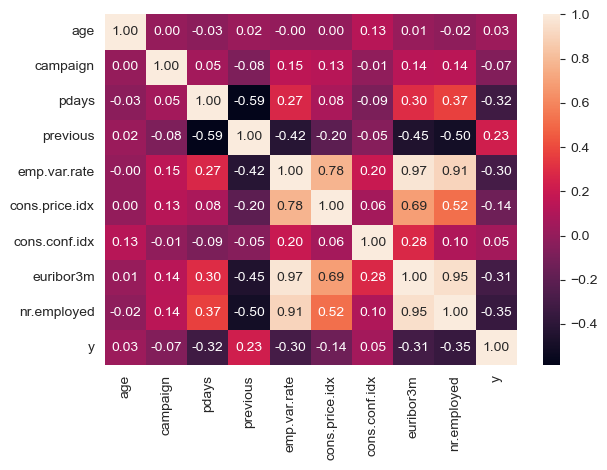

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.tight_layout()
plt.savefig('correlation_matrix.png')

In [30]:
df = df.drop(["emp.var.rate", "euribor3m"], axis=1)

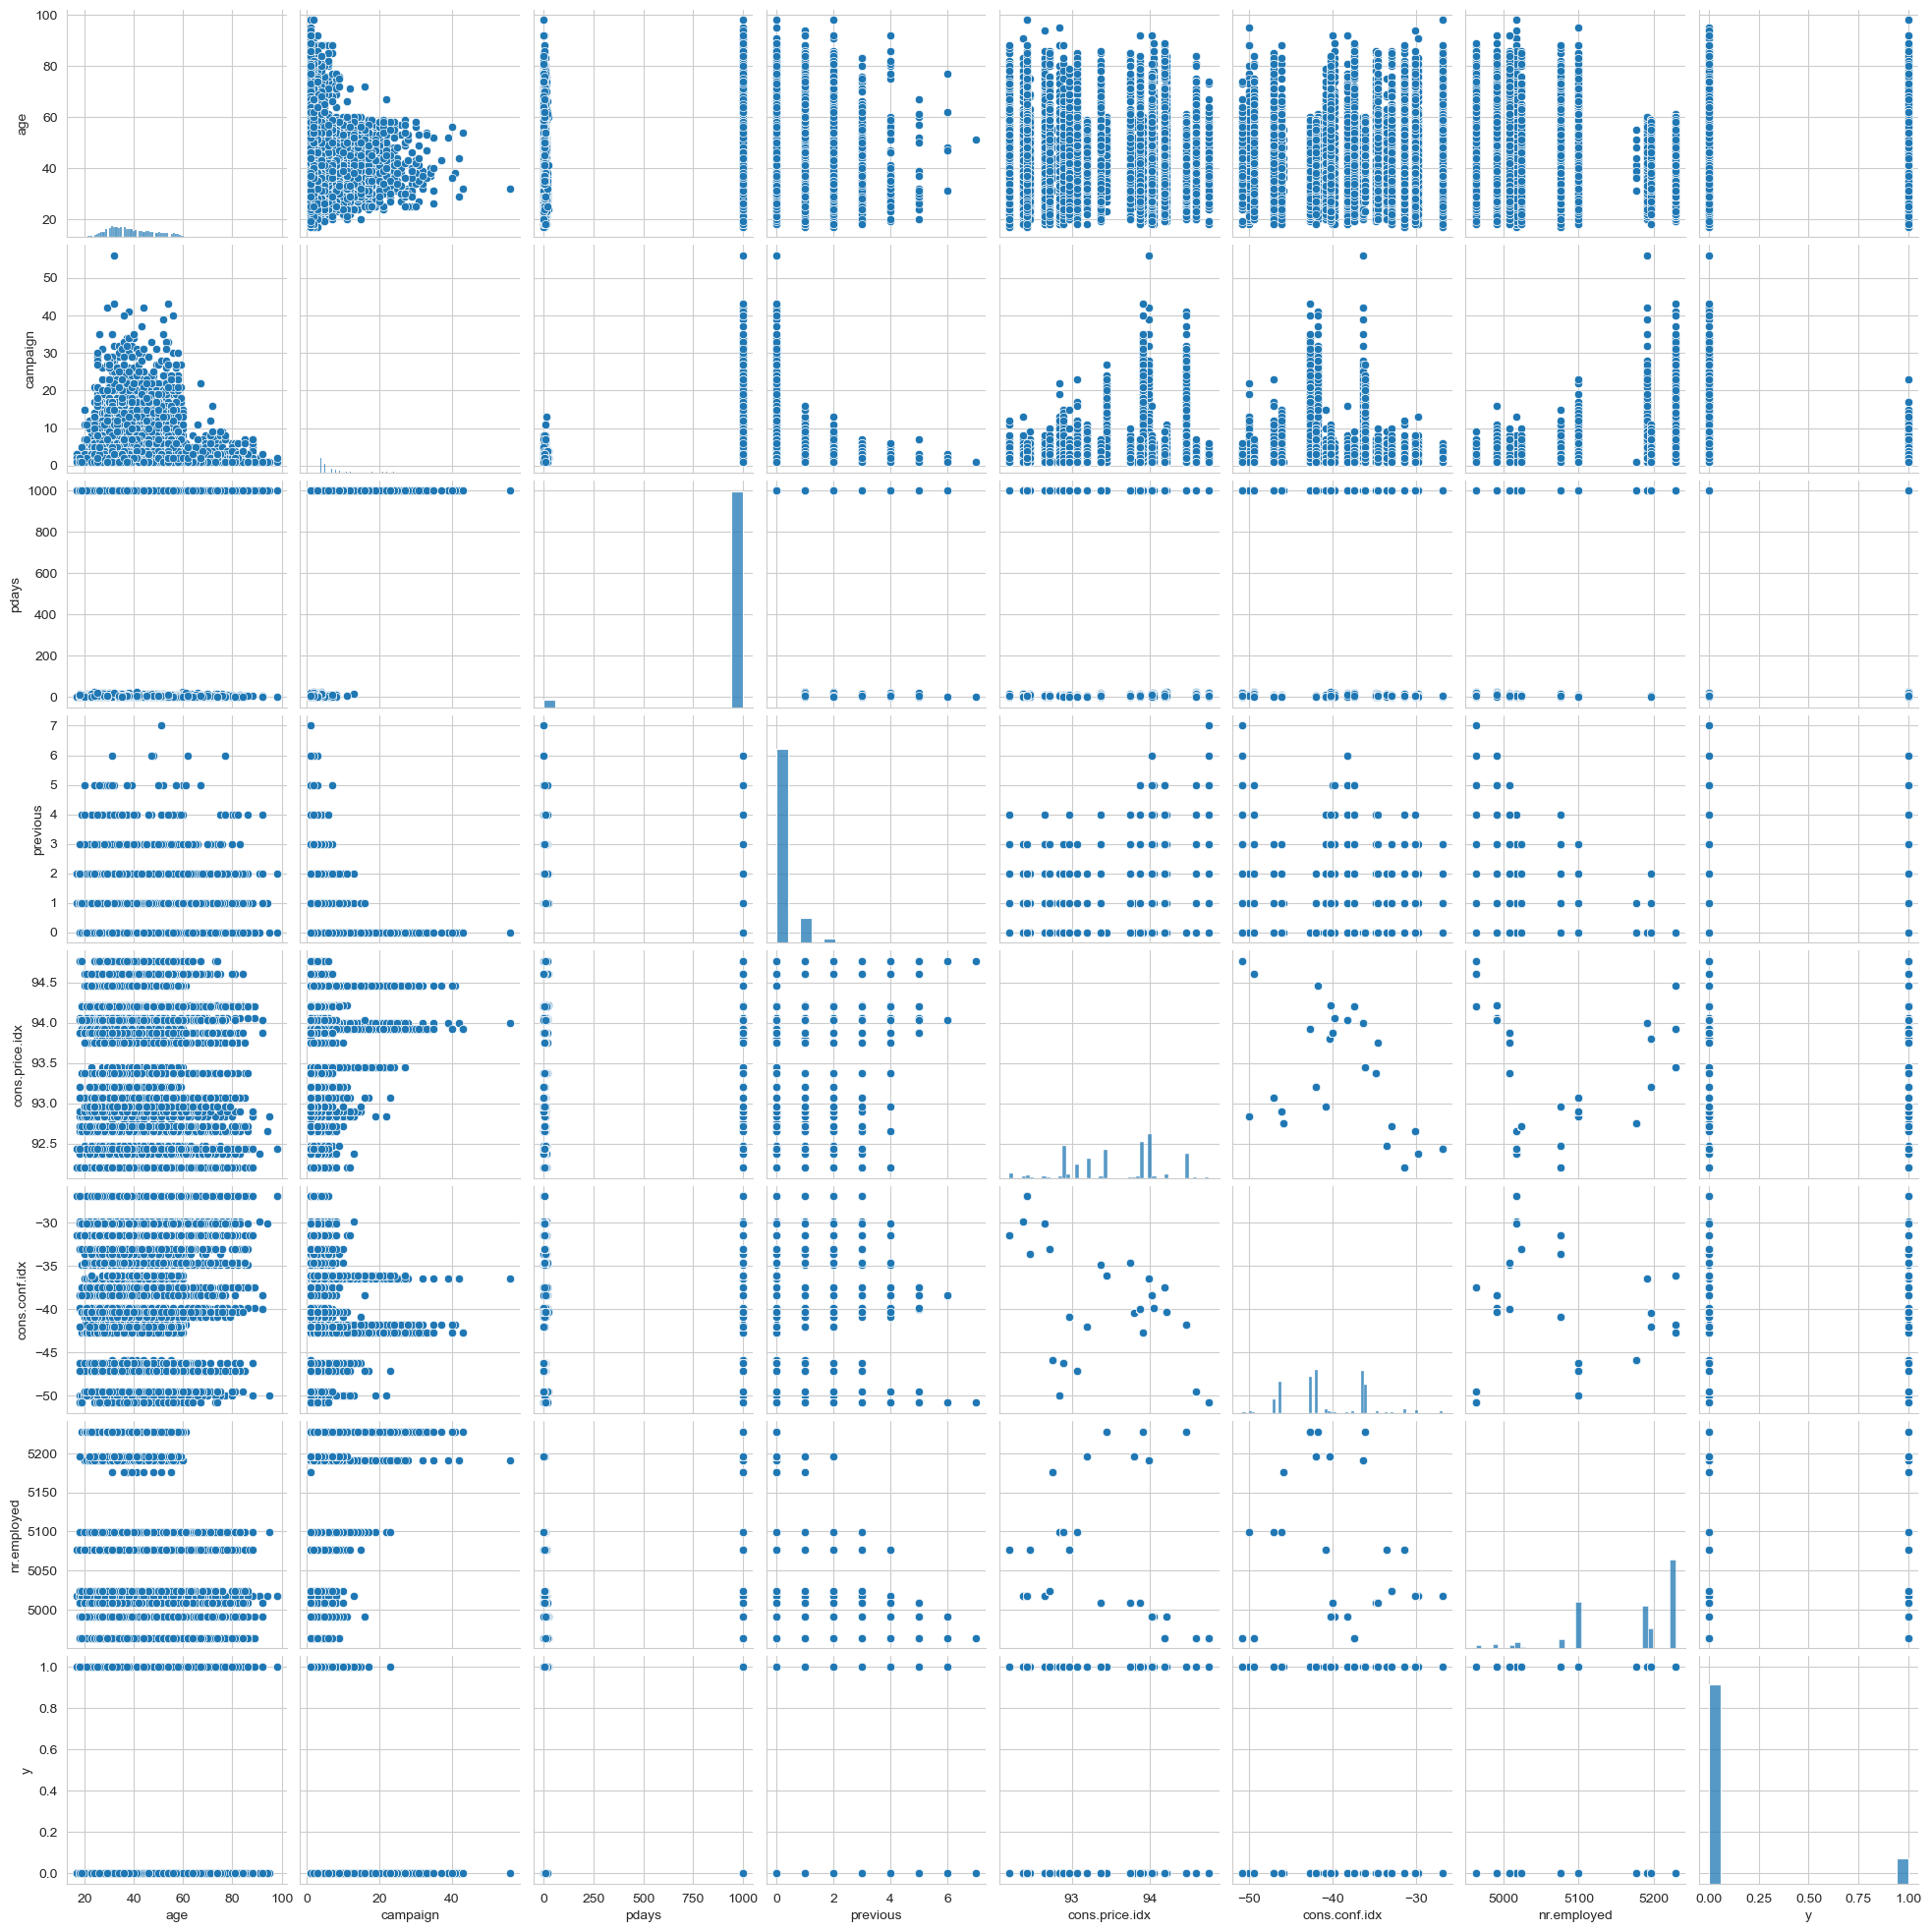

In [31]:
sns.pairplot(df)

In [33]:
X = df.drop('y', axis=1)
y= df['y']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerische Features ({len(numerical_features)}): {numerical_features}")
print(f"Kategoriale Features ({len(categorical_features)}): {categorical_features}")

Numerische Features (7): ['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
Kategoriale Features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

LOGISTIC REGRESSION

In [37]:
base_clf = LogisticRegression(max_iter=500, solver="lbfgs", class_weight="balanced")

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',base_clf)
])

In [38]:
log_reg_pipeline.fit(X_train, y_train)
baseline_acc = log_reg_pipeline.score(X_test, y_test)
print(f"Baseline Test Accuracy: {baseline_acc:.3f}")

y_pred_base = log_reg_pipeline.predict(X_test)
print("Baseline Test F1-macro:", f1_score(y_test, y_pred_base, average="macro"))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred_base))

Baseline Test Accuracy: 0.829
Baseline Test F1-macro: 0.6785686544192573

Detailed classification report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



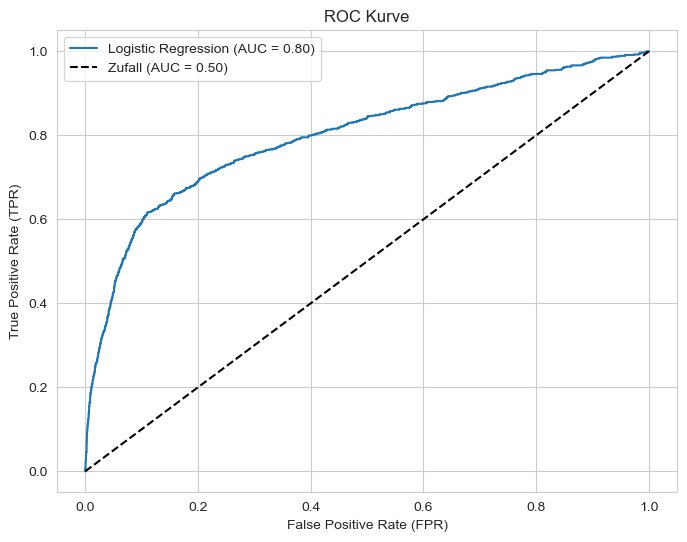

In [41]:
y_scores = log_reg_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_value = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Zufall (AUC = 0.50)') # Diagonale Linie
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Kurve')
plt.legend()
plt.savefig('roc_curve_logreg.png')
plt.show()

RANDOM FOREST

In [42]:
rf = RandomForestClassifier(random_state=42)

rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("classifier", rf)
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("RandomForest – Test Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print("RandomForest – Test F1-macro:",
      f1_score(y_test, y_pred_rf, average="macro"))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred_rf))

RandomForest – Test Accuracy: 0.8923282350084972
RandomForest – Test F1-macro: 0.6588719389662733

Detailed classification report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.54      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238



RandomForest – ROC AUC: 0.7739


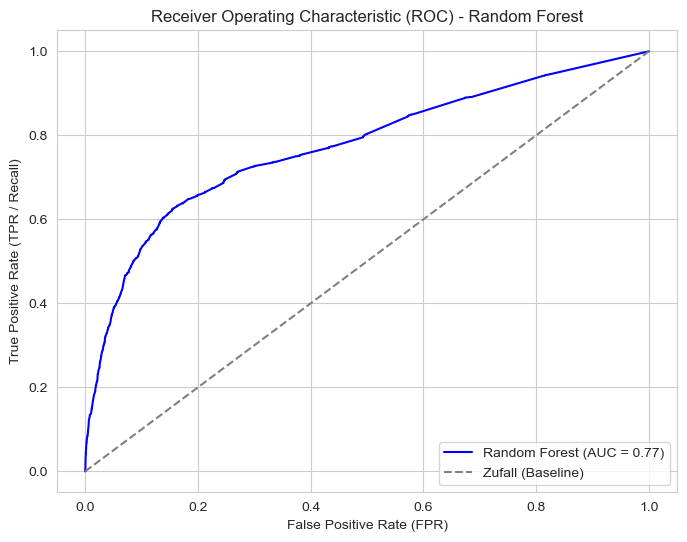

In [44]:
y_probs_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_probs_rf)
print(f"RandomForest – ROC AUC: {rf_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Zufall (Baseline)')

plt.title('Receiver Operating Characteristic (ROC) - Random Forest')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('roc_curve_rf.png')
plt.show()

XGBOOST

Berechnetes scale_pos_weight: 7.88
XGBoost – Test Accuracy: 0.8452294246176256
XGBoost – Test F1-macro: 0.6878974564658188

Detailed classification report (XGBoost):
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.38      0.60      0.47       928

    accuracy                           0.85      8238
   macro avg       0.66      0.74      0.69      8238
weighted avg       0.88      0.85      0.86      8238



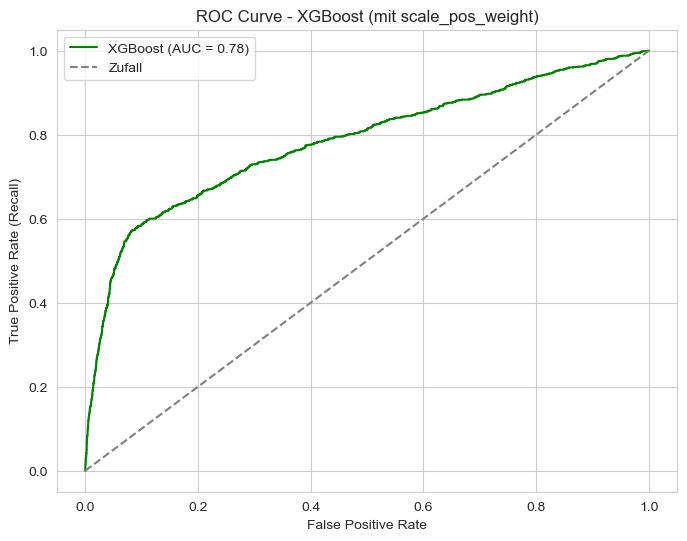

In [46]:
count_class_0 = np.sum(y_train == 0)
count_class_1 = np.sum(y_train == 1)
scale_weight = count_class_0 / count_class_1

print(f"Berechnetes scale_pos_weight: {scale_weight:.2f}")

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_weight,
)

xgb_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("classifier", xgb_clf)
])


xgb_pipeline.fit(X_train, y_train)


y_pred_xgb = xgb_pipeline.predict(X_test)
y_probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1] # Für ROC


print("XGBoost – Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost – Test F1-macro:", f1_score(y_test, y_pred_xgb, average="macro"))

print("\nDetailed classification report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))


xgb_auc = roc_auc_score(y_test, y_probs_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='green', label=f'XGBoost (AUC = {xgb_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Zufall')
plt.title('ROC Curve - XGBoost (mit scale_pos_weight)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)
plt.savefig("roc_curve_xgb.png")
plt.show()

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Beste Parameter: {'classifier__subsample': 0.7, 'classifier__scale_pos_weight': 7.876616379310345, 'classifier__n_estimators': 300, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}
Bester CV-Score (AUC): 0.792743096887486


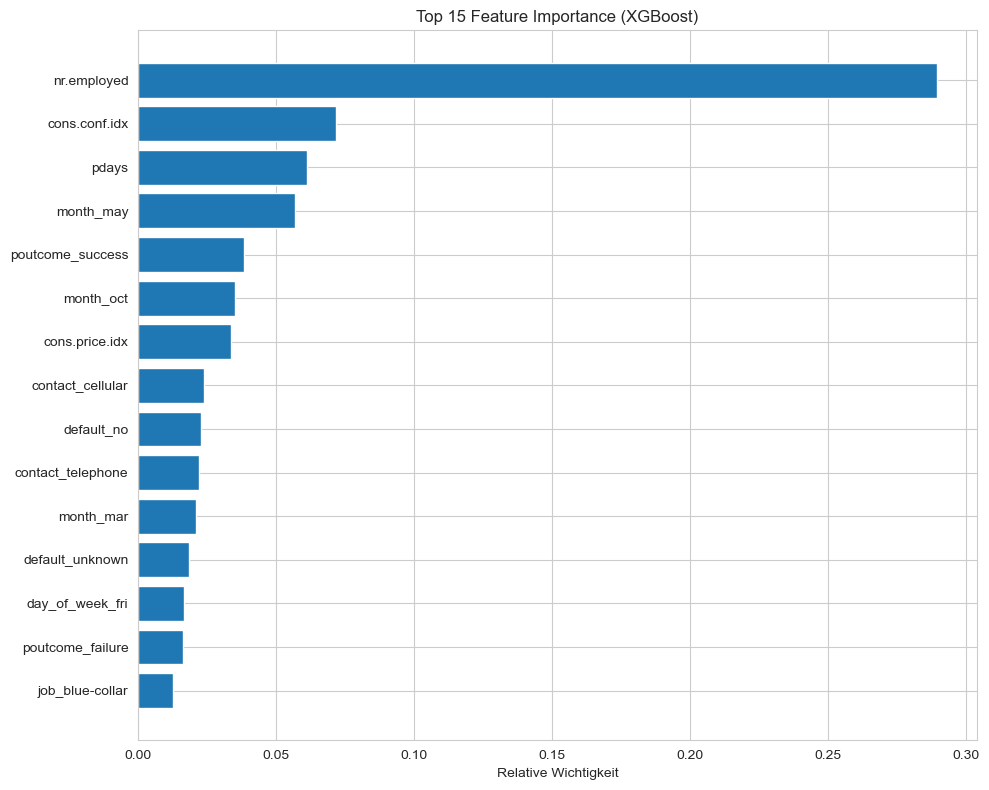

In [54]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],
    'classifier__scale_pos_weight': [scale_weight] # Dein berechnetes Gewicht
}

xgb_tuned = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
pipeline_tuned = Pipeline(steps=[
    ("prep", preprocessor),
    ("classifier", xgb_tuned)
])

search = RandomizedSearchCV(
    pipeline_tuned,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc', # Wir optimieren auf AUC
    n_jobs=-1,
    cv=5,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

print("Beste Parameter:", search.best_params_)
print("Bester CV-Score (AUC):", search.best_score_)


best_model = search.best_estimator_

xgb_best = best_model.named_steps['classifier']

onehot_cols = best_model.named_steps['prep'].transformers_[1][1]['onehot'].get_feature_names_out(categorical_features)
feature_names = np.r_[numerical_features, onehot_cols]

plt.figure(figsize=(10, 8))

importances = xgb_best.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 Features

plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Wichtigkeit')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

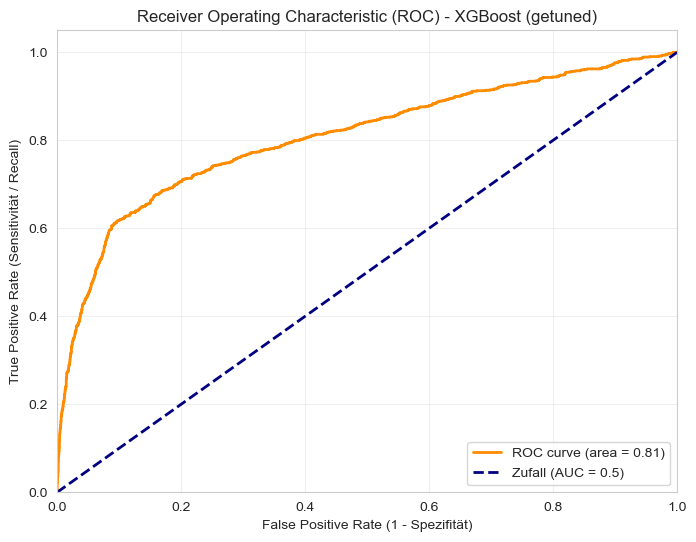

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Zufall (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Spezifität)')
plt.ylabel('True Positive Rate (Sensitivität / Recall)')
plt.title('Receiver Operating Characteristic (ROC) - XGBoost (getuned)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_curve_xgboost_tuned.png")
plt.show()

In [58]:
y_pred = best_model.predict(X_test)

print("\n--- Classification Report ---")

print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d') 
plt.title('Confusion Matrix (Test Set)')
plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.49       928

    accuracy                           0.85      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.85      0.86      8238



NameError: name 'ConfusionMatrixDisplay' is not defined

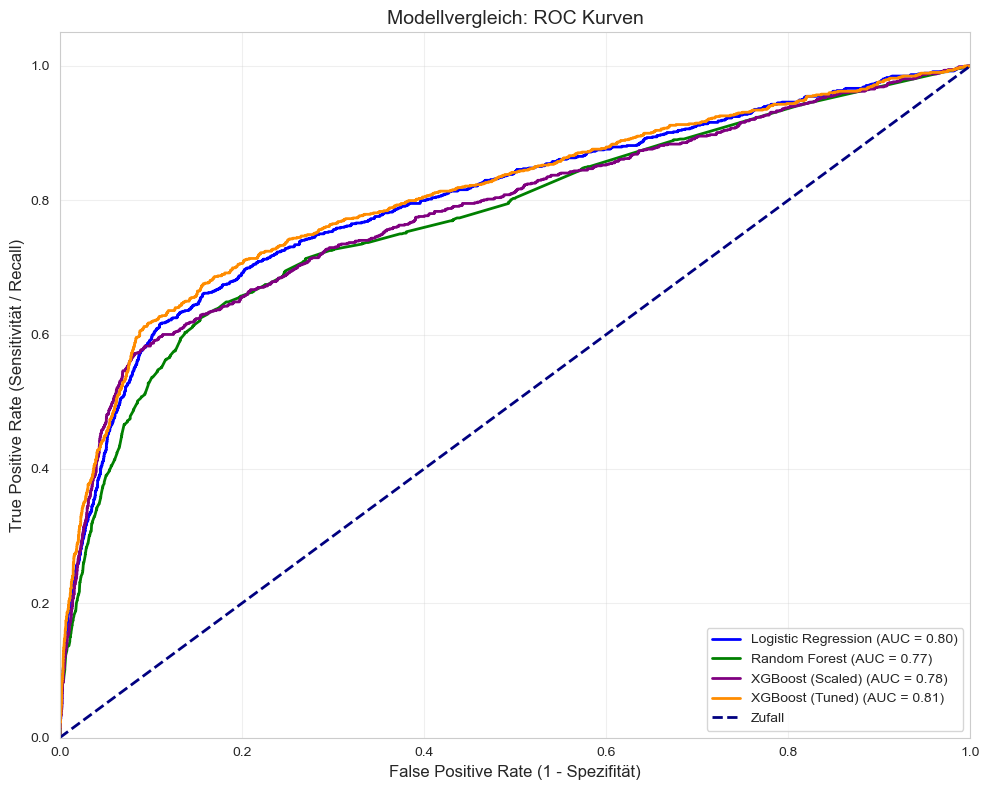

In [61]:
plt.figure(figsize=(10, 8))

models = [
    ('Logistic Regression', log_reg_pipeline, 'blue'),
    ('Random Forest', rf_pipeline, 'green'),
    ('XGBoost (Scaled)', xgb_pipeline, 'purple'),
    ('XGBoost (Tuned)', best_model, 'darkorange')
]

for name, model, color in models:
    y_probs = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_probs)
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Zufall')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Spezifität)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivität / Recall)', fontsize=12)
plt.title('Modellvergleich: ROC Kurven', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('alle_roc_kurven_vergleich.png')
plt.show()

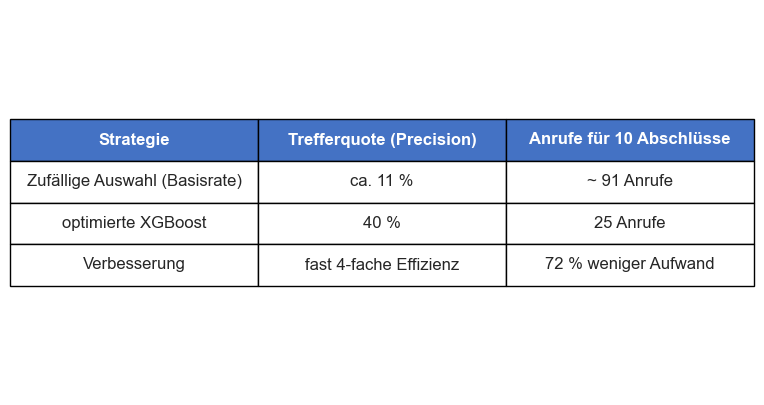

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Strategie": [
        "Zufällige Auswahl (Basisrate)", 
        "optimierte XGBoost", # Hier wurde der Text angepasst
        "Verbesserung"
    ],
    "Trefferquote (Precision)": [
        "ca. 11 %", 
        "40 %", 
        "fast 4-fache Effizienz"
    ],
    "Anrufe für 10 Abschlüsse": [
        "~ 91 Anrufe", 
        "25 Anrufe", 
        "72 % weniger Aufwand"
    ]
}

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')

table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=["#4472C4"] * len(df.columns))

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5)

for i in range(len(df.columns)):
    table[0, i].get_text().set_color('white')
    table[0, i].get_text().set_weight('bold')


plt.savefig('effizienz_vergleich_aktualisiert.png', bbox_inches='tight', dpi=300)
plt.show()